In [3]:
import sys
import os

# Working directory ko project root pe set karein
os.chdir('..')
sys.path.append('.')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_ratings, load_movies, load_users

%matplotlib inline

In [4]:
ratings = load_ratings()
movies = load_movies()
users = load_users()

print(f"Total Users: {ratings.user_id.nunique()}")
print(f"Total Movies: {ratings.item_id.nunique()}")
print(f"Total Ratings: {len(ratings)}")

ratings.head()

Total Users: 943
Total Movies: 1682
Total Ratings: 100000


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [5]:
n_users = ratings.user_id.nunique()
n_movies = ratings.item_id.nunique()
n_ratings = len(ratings)

possible_ratings = n_users * n_movies
sparsity = 1 - (n_ratings / possible_ratings)

print(f"Possible user-movie combinations: {possible_ratings}")
print(f"Actual ratings given: {n_ratings}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")

Possible user-movie combinations: 1586126
Actual ratings given: 100000
Sparsity: 0.9370 (93.70%)


C:\Users\noorf\AppData\Local\Temp\ipykernel_8336\2061701088.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


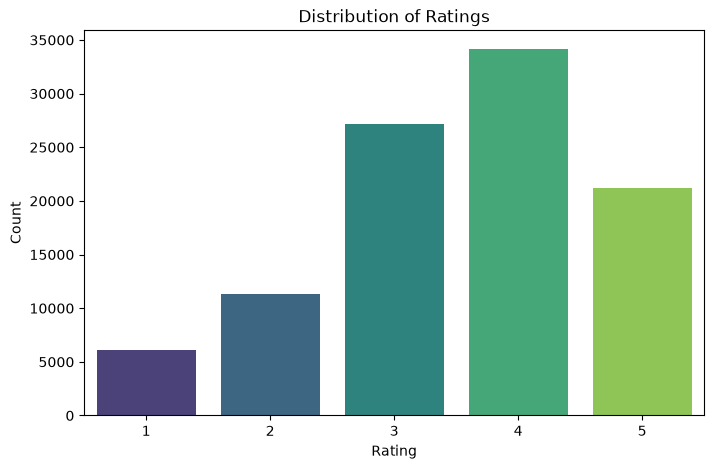

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig('notebooks/rating_distribution.png')
plt.show()

Average ratings per user: 106.04
Minimum ratings per user: 20
Maximum ratings per user: 737


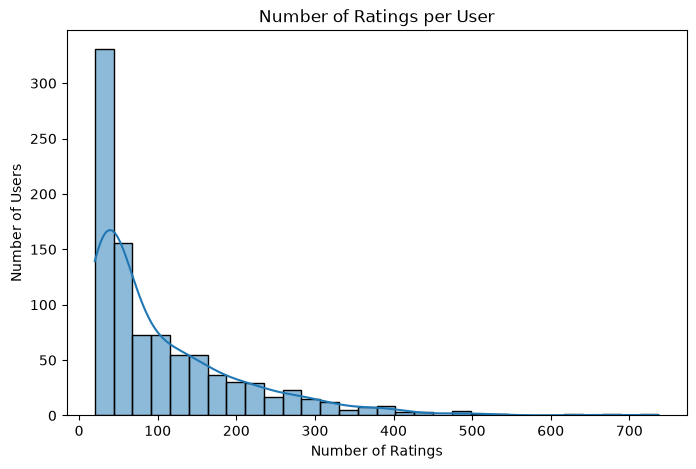

In [7]:
ratings_per_user = ratings.groupby('user_id')['rating'].count()

print(f"Average ratings per user: {ratings_per_user.mean():.2f}")
print(f"Minimum ratings per user: {ratings_per_user.min()}")
print(f"Maximum ratings per user: {ratings_per_user.max()}")

plt.figure(figsize=(8, 5))
sns.histplot(ratings_per_user, bins=30, kde=True)
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.savefig('notebooks/ratings_per_user.png')
plt.show()

Average ratings per movie: 59.45
Minimum ratings per movie: 1
Maximum ratings per movie: 583

Movies with fewer than 5 ratings (cold-start items): 333 out of 1682


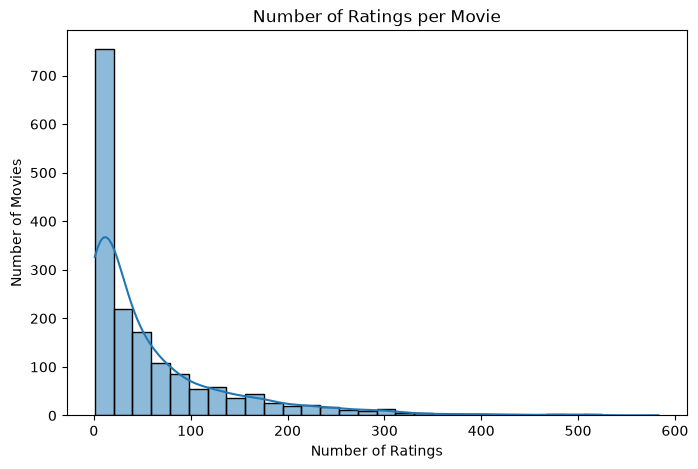

In [8]:
ratings_per_movie = ratings.groupby('item_id')['rating'].count()

print(f"Average ratings per movie: {ratings_per_movie.mean():.2f}")
print(f"Minimum ratings per movie: {ratings_per_movie.min()}")
print(f"Maximum ratings per movie: {ratings_per_movie.max()}")

# Kitni movies ko bohat kam (5 se kam) ratings mili — ye cold-start items hain
cold_movies = (ratings_per_movie < 5).sum()
print(f"\nMovies with fewer than 5 ratings (cold-start items): {cold_movies} out of {n_movies}")

plt.figure(figsize=(8, 5))
sns.histplot(ratings_per_movie, bins=30, kde=True)
plt.title('Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.savefig('notebooks/ratings_per_movie.png')
plt.show()

In [9]:
top_movies = ratings.groupby('item_id')['rating'].count().sort_values(ascending=False).head(10)
top_movies_titles = movies.set_index('item_id').loc[top_movies.index, 'title']

top_movies_df = pd.DataFrame({
    'title': top_movies_titles,
    'num_ratings': top_movies.values
})

print("Top 10 Most Rated Movies:")
top_movies_df

Top 10 Most Rated Movies:


,title,num_ratings
item_id,,
50,Star Wars (1977),583
258,Contact (1997),509
100,Fargo (1996),508
181,Return of the Jedi (1983),507
294,Liar Liar (1997),485
286,"English Patient, The (1996)",481
288,Scream (1996),478
1,Toy Story (1995),452
300,Air Force One (1997),431


## EDA Summary

- Dataset: MovieLens 100K (943 users, 1682 movies, 100,000 ratings)
- Sparsity: ~93.7% — matlab bohat kam user-movie combinations mein actual rating maujood hai
- Ratings ka distribution: 4 aur 3 sabse common ratings hain, users generally positive rate karte hain
- Har user ne average ~106 movies rate ki hain, lekin range bohat wide hai (min se max tak)
- Long-tail problem: Kai movies ko bohat kam ratings mili hain — ye cold-start challenge ko highlight karta hai
- Top-rated movies mein popular 90s films hain (Star Wars, Toy Story, etc.)

**Implication for RecoLab:** Sparsity aur long-tail distribution ki wajah se sirf collaborative filtering kaafi nahi hoga naye/kam-rated items ke liye — isliye hybrid approach (collaborative + content-based) zaroori hai taake cold-start items bhi recommend ho sakein.